In [43]:
import pandas as pd #Used for data handling, cleaning, filtering, and grouping
import numpy as np #Useful for numerical operations and handling missing/infinite values.
import matplotlib.pyplot as plt #Used for plotting graphs / data visualization
from matplotlib.ticker import FuncFormatter #Used for formatting numbers on plot axes

# Load dataset from CSV file into a DataFrame
# This file contains company financial and sector information
df_raw = pd.read_csv(r"data\Symbol_Info_extended2.csv")

# Show first 5 rows to understand dataset structure and columns
df_raw.head()

,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,1.290000e+09,7.065000e+09,0.08533,0.19946,...,25.377481,17.515205,-0.036,4.598437,4.704534,0.070,51.390,0.89,0.2205,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,1.027000e+09,1.265500e+10,0.04241,0.15427,...,18.302563,10.659156,-0.227,1.488460,2.759500,-0.052,37.019,0.56,0.1026,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,2.020000e+08,5.599400e+10,0.01846,NaN,...,44.677420,6.256155,NaN,0.163592,-2.246918,0.108,NaN,NaN,0.0000,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,8.420000e+07,6.108000e+08,0.12664,1.11725,...,30.459576,12.513987,0.264,4.175381,32.910347,0.393,346.579,0.56,0.0553,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-4.333700e+07,5.070000e+08,-0.03317,-0.06126,...,NaN,38.032272,NaN,28.724379,12.958943,0.514,25.356,NaN,0.0000,-4.455833e+08


In [ ]:
# Filter Canadian companies and sort them by market cap
df_raw[df_raw["country"] == "Canada"][
    ["symbol", "company_name", "industry", "market_cap"]
].sort_values("market_cap", ascending=False).head(20)

,symbol,company_name,industry,market_cap
2389,RY,Royal Bank of Canada,Banks - Diversified,2.637950e+11
2656,TD,The Toronto-Dominion Bank,Banks - Diversified,1.875740e+11
2473,SHOP,Shopify Inc.,Software - Application,1.336580e+11
918,ENB,Enbridge Inc.,Oil & Gas Midstream,1.267420e+11
408,BMO,Bank of Montreal,Banks - Diversified,1.134430e+11
608,CM,Canadian Imperial Bank of Commerce,Banks - Diversified,1.062910e+11
635,CNQ,Canadian Natural Resources Limited,Oil & Gas E&P,1.013860e+11
412,BN,Brookfield Corporation,Asset Management,1.013380e+11
414,BNS,The Bank of Nova Scotia,Banks - Diversified,9.824377e+10
63,AEM,Agnico Eagle Mines Limited,Gold,8.796137e+10


In [47]:
# Load dataset from CSV file into a DataFrame
df = pd.read_csv(r"data\Symbol_Info_extended2.csv")

# Replace infinite values (inf, -inf) with NaN to avoid calculation errors
df = df.replace([np.inf, -np.inf], np.nan)

# Define selected company symbol (Royal Bank of Canada)
selected_symbol = "RY"

# Extract only the selected company row for later comparison
df_selected = df[df["symbol"] == selected_symbol].copy()

# Define only required columns for analysis (as required by assignment)
cols_required = [
    "symbol", "company_name", "sector", "industry", "country", "market_cap",
    "return_on_assets", "return_on_equity", "profit_margins",
    "pe_trailing", "price_to_book",
    "revenue_growth", "debt_to_equity", "free_cashflow"
]

# Keep only relevant columns for analysis
df_clean = df[cols_required].copy()

# Set invalid valuation values (<= 0) to NaN because they are not comparable
df_clean.loc[df_clean["pe_trailing"] <= 0, "pe_trailing"] = np.nan
df_clean.loc[df_clean["price_to_book"] <= 0, "price_to_book"] = np.nan

# Remove companies with invalid or missing market cap
df_clean = df_clean[df_clean["market_cap"] > 0]

In [52]:
# Display first rows of cleaned dataset to verify structure
df_clean.head()

# Filter dataset to show only Royal Bank of Canada (RY)
df_clean[df_clean["symbol"] == "RY"]

# Some financial metrics contain missing values (NaN), which is common in real-world datasets.

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
2389,RY,Royal Bank of Canada,Financial Services,Banks - Diversified,Canada,2.637950e+11,0.00927,0.15395,0.33137,17.91407,2.863501,0.075,NaN,NaN


In [54]:
# Step 2 :
# Get industry of selected company (RY)
ry_industry = df_clean[df_clean["symbol"] == "RY"]["industry"].values[0]

# ------------------------------------------------------------
# Group A: Same Industry peers (most important comparison group)
# ------------------------------------------------------------
df_A = df_clean[df_clean["industry"] == ry_industry].copy()

# Sort companies in same industry by market capitalization (largest first)
df_A = df_A.sort_values("market_cap", ascending=False)


# ------------------------------------------------------------
# Group B: Same country peers (Canada in this case)
# ------------------------------------------------------------
df_B = df_clean[df_clean["country"] == "Canada"].copy()

# Sort Canadian companies by market capitalization
df_B = df_B.sort_values("market_cap", ascending=False)


# ------------------------------------------------------------
# Group C: Closest companies by market cap (size similarity)
# ------------------------------------------------------------

# Get market cap of selected company (RY)
ry_cap = df_clean[df_clean["symbol"] == "RY"]["market_cap"].values[0]

# Calculate absolute distance between each company and RY by market cap
df_clean["cap_distance"] = abs(df_clean["market_cap"] - ry_cap)

# Select 10 closest companies by market cap
df_C = df_clean.sort_values("cap_distance").head(10)

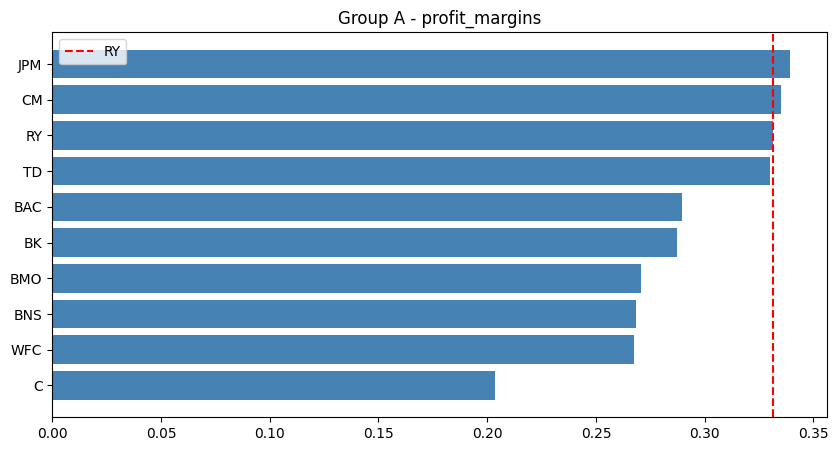

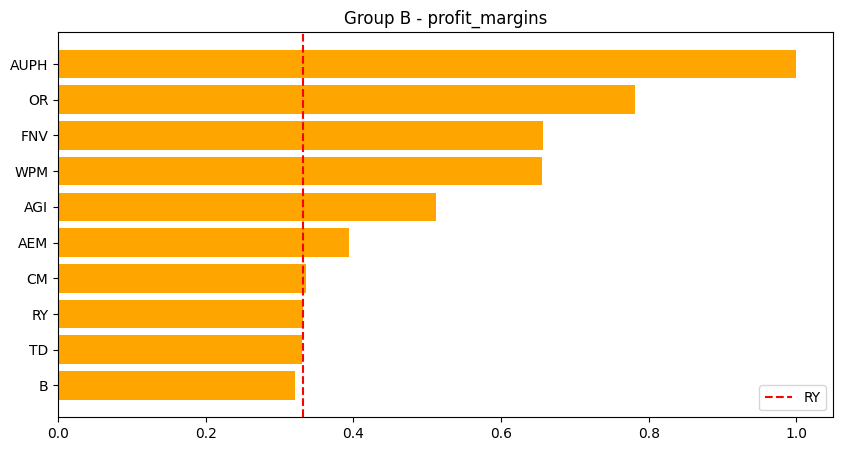

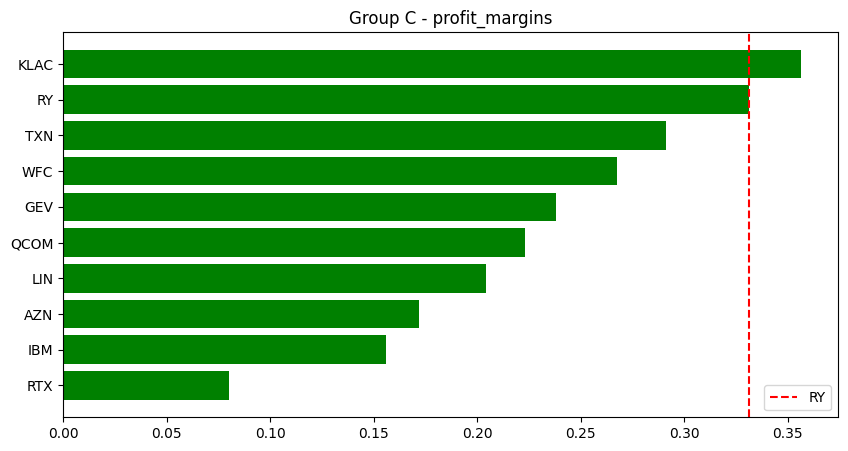

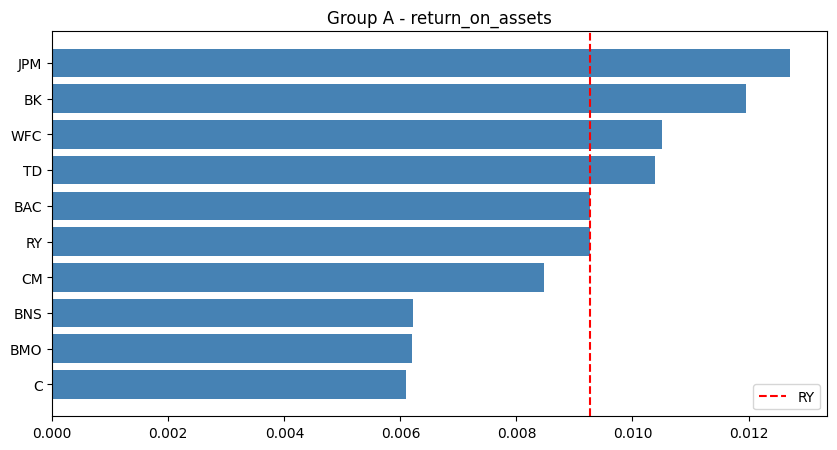

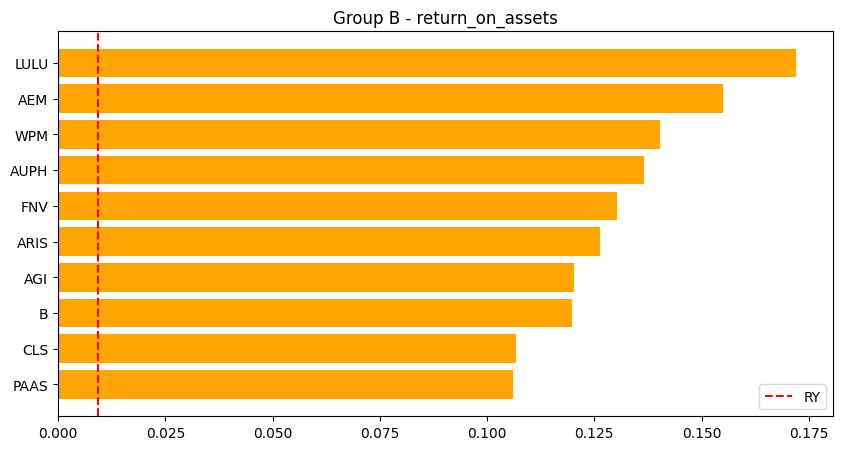

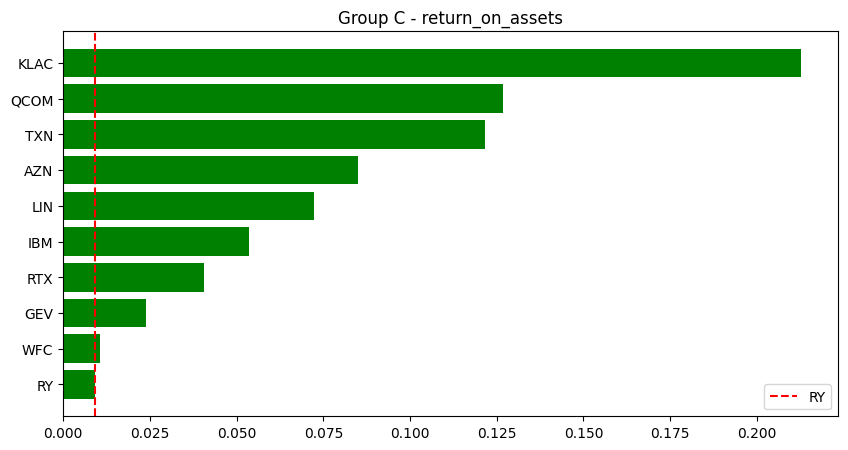

In [57]:
# Step 3: Profitability analysis (ONLY required output)

metrics = ["profit_margins", "return_on_assets"]

for m in metrics:
    
    # =====================
    # Group A (Industry)
    # =====================
    data_A = df_A[["symbol", m]].dropna().sort_values(m)

    plt.figure(figsize=(10,5))
    plt.barh(data_A["symbol"], data_A[m], color="steelblue")

    ry_val = df_clean.loc[df_clean["symbol"]=="RY", m].dropna()
    if not ry_val.empty:
        plt.axvline(ry_val.values[0], color="red", linestyle="--", label="RY")

    plt.title(f"Group A - {m}")
    plt.legend()
    plt.show()


    # =====================
    # Group B (Canada)
    # =====================
    data_B = df_B[["symbol", m]].dropna().sort_values(m).tail(10)

    plt.figure(figsize=(10,5))
    plt.barh(data_B["symbol"], data_B[m], color="orange")

    if not ry_val.empty:
        plt.axvline(ry_val.values[0], color="red", linestyle="--", label="RY")

    plt.title(f"Group B - {m}")
    plt.legend()
    plt.show()


    # =====================
    # Group C (Market Cap)
    # =====================
    data_C = df_C[["symbol", m]].dropna().sort_values(m)

    plt.figure(figsize=(10,5))
    plt.barh(data_C["symbol"], data_C[m], color="green")

    if not ry_val.empty:
        plt.axvline(ry_val.values[0], color="red", linestyle="--", label="RY")

    plt.title(f"Group C - {m}")
    plt.legend()
    plt.show()

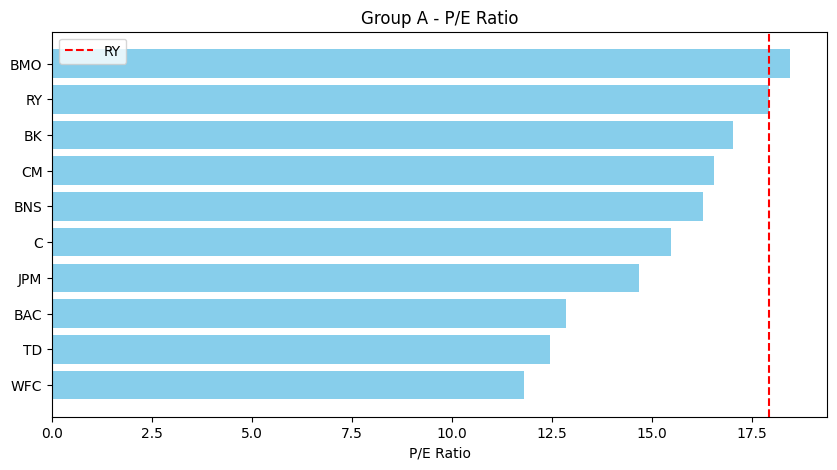

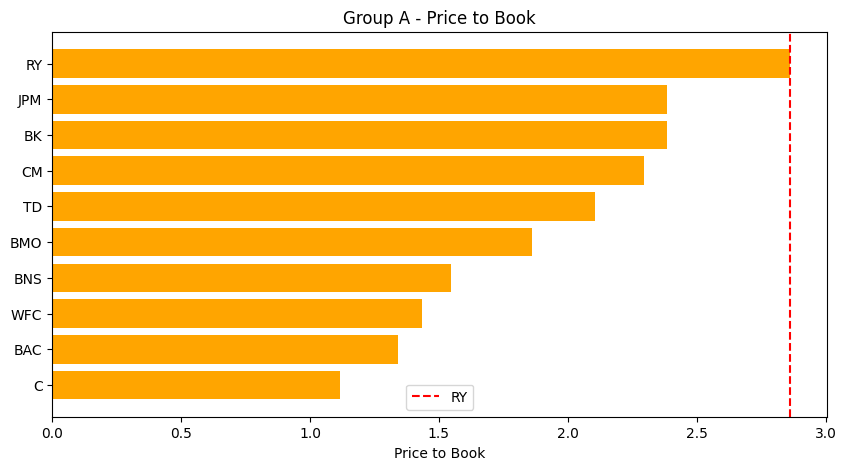

In [58]:
# Step 4: Valuation analysis (Group A only)

df_A_val = df_A.copy()

# ---------------------------------
# Clean invalid valuation values
# ---------------------------------
df_A_val.loc[df_A_val["pe_trailing"] <= 0, "pe_trailing"] = np.nan
df_A_val.loc[df_A_val["price_to_book"] <= 0, "price_to_book"] = np.nan


# =========================
# P/E RATIO
# =========================
data_pe = df_A_val[["symbol", "pe_trailing"]].dropna().sort_values("pe_trailing")

plt.figure(figsize=(10,5))
plt.barh(data_pe["symbol"], data_pe["pe_trailing"], color="skyblue")

ry_pe = df_A_val.loc[df_A_val["symbol"] == "RY", "pe_trailing"].dropna()

if not ry_pe.empty:
    plt.axvline(ry_pe.values[0], color="red", linestyle="--", label="RY")

plt.title("Group A - P/E Ratio")
plt.xlabel("P/E Ratio")
plt.legend()
plt.show()


# =========================
# PRICE TO BOOK
# =========================
data_pb = df_A_val[["symbol", "price_to_book"]].dropna().sort_values("price_to_book")

plt.figure(figsize=(10,5))
plt.barh(data_pb["symbol"], data_pb["price_to_book"], color="orange")

ry_pb = df_A_val.loc[df_A_val["symbol"] == "RY", "price_to_book"].dropna()

if not ry_pb.empty:
    plt.axvline(ry_pb.values[0], color="red", linestyle="--", label="RY")

plt.title("Group A - Price to Book")
plt.xlabel("Price to Book")
plt.legend()
plt.show()

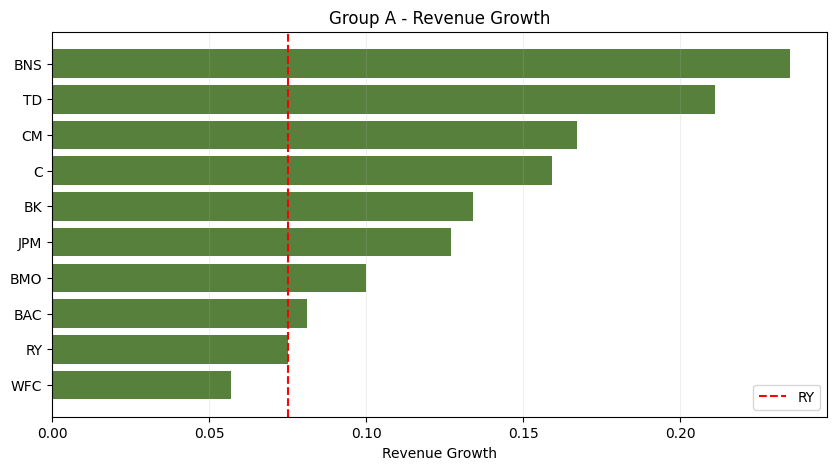

In [60]:
# Step 5: Growth analysis (Group A only)

# Create a copy of Group A for growth analysis
df_A_growth = df_A.copy()

# Remove missing values for revenue growth only
df_A_growth = df_A_growth.dropna(subset=["revenue_growth"])

# Cap extreme outliers to keep chart readable
df_A_growth["revenue_growth"] = df_A_growth["revenue_growth"].clip(-0.5, 1.0)

# Sort companies by revenue growth
data = df_A_growth[["symbol", "revenue_growth"]].sort_values("revenue_growth")

# Plot revenue growth comparison
plt.figure(figsize=(10,5))
plt.barh(data["symbol"], data["revenue_growth"], color="#58803D")

# Highlight RY if value exists
ry_value = df_A_growth.loc[df_A_growth["symbol"] == "RY", "revenue_growth"].dropna()

if not ry_value.empty:
    plt.axvline(ry_value.values[0], color="red", linestyle="--", label="RY")

plt.title("Group A - Revenue Growth")
plt.xlabel("Revenue Growth")
plt.legend()
plt.grid(axis="x", alpha=0.2)
plt.show()

# Interpretation of revenue growth:
# If RY shows higher revenue growth than peers, this means the company is expanding faster than competitors.
# If RY shows lower revenue growth, this is normal for a mature company like a bank, showing stable but slower growth.
# If RY is close to the peer median, this indicates normal industry behavior with no major deviation.

In [61]:
# Step 6: Financial strength analysis (Group A only)

df_A_fin = df_A.copy()

metrics = ["debt_to_equity", "free_cashflow"]

for m in metrics:
    
    # Remove missing values for each metric separately
    data = df_A_fin[["symbol", m]].dropna().sort_values(m)

    # Skip if no valid data exists
    if data.empty:
        print(f"No valid data available for {m} in Group A")
        continue

    # Plot horizontal bar chart
    plt.figure(figsize=(10,5))
    plt.barh(data["symbol"], data[m], color="steelblue")

    # Highlight RY safely
    ry_row = df_A_fin.loc[df_A_fin["symbol"] == "RY", m].dropna()

    if not ry_row.empty:
        plt.axvline(ry_row.values[0], color="red", linestyle="--", label="RY")
    else:
        print(f"RY has no valid value for {m}")

    # Titles and styling
    plt.title(f"Group A - {m}")
    plt.xlabel(m)
    plt.legend()
    plt.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

No valid data available for debt_to_equity in Group A
No valid data available for free_cashflow in Group A


# Final Summary

In this analysis, I selected Royal Bank of Canada (RY) because it is one of the largest banks in Canada and has a strong and stable position in the financial sector. It is a mature company, which makes it useful for comparing profitability, valuation, growth, and financial strength against similar companies.

From the profitability analysis, RY shows results that are mostly in line with other large banks. In some cases it is close to the peer median, which suggests stable performance rather than very strong or weak outperformance. Both profit margins and return on assets generally point to a consistent profitability profile.

In terms of valuation, RY appears to be fairly valued compared to its peers. The P/E ratio and price-to-book ratio do not show extreme differences, which means the market sees it as a stable and mature company rather than a high-growth opportunity.

For growth, RY shows moderate revenue growth. This is expected for a large banking institution, since banks usually grow at a steady and stable rate rather than very fast. The growth results are consistent with the valuation results.

In the financial strength analysis, RY shows a balanced structure. Debt levels are in line with what is normal for banks, since leverage is part of the industry. Free cash flow can vary depending on the business cycle, so it is not always strong, but it does not show serious financial issues. Some missing values were present in the dataset, and they were not filled, as required.

Overall, RY is a stable and low-risk company with consistent profitability, moderate growth, and fair valuation. It behaves like a mature bank rather than a high-growth company. Even though some data was missing, the available information was enough to reach a clear conclusion.